In [1]:
# Instalación de skore.

%pip install -U skore[hub]

  Using cached httpx-0.28.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached httpcore-1.0.9-py3-none-any.whl.metadata (21 kB)
  Using cached h11-0.16.0-py3-none-any.whl.metadata (8.3 kB)
   ---------------------------------------- 0.0/585.9 kB ? eta -:--:--
   ----------------------------------- ---- 524.3/585.9 kB 8.2 MB/s eta 0:00:01
   ---------------------------------------- 585.9/585.9 kB 1.6 MB/s eta 0:00:00
Using cached httpx-0.28.1-py3-none-any.whl (73 kB)
Using cached httpcore-1.0.9-py3-none-any.whl (78 kB)
Using cached h11-0.16.0-py3-none-any.whl (37 kB)

   ----------------------------------------  0/10 [uuid6]
   ----------------------------------------  0/10 [uuid6]
   ---- -----------------------------------  1/10 [pydot]
   ---- -----------------------------------  1/10 [pydot]
   ---- -----------------------------------  1/10 [pydot]
   ---- -----------------------------------  1/10 [pydot]
   -------- -------------------------------  2/10 [orjson]
   ------------ ----


[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Let’s start by loading the “toxicity” dataset, a classification problem where we classify tweets as “toxic” or “not toxic”.

from skrub import TableReport, datasets

toxicity = datasets.fetch_toxicity()
X, y = toxicity.X, toxicity.y
TableReport(toxicity.toxicity)

Processing column   2 / 2


<TableReport: use .open() or .markdown() to display>

In [3]:
# We create a held-out test set to evaluate our final model once we are done experimenting.

from sklearn.model_selection import train_test_split

X_experiment, X_holdout, y_experiment, y_holdout = train_test_split(
    X, y, random_state=0
)

# Model no. 1:

In [4]:
# Model no. 1: logistic regression with preprocessing.

from sklearn.linear_model import LogisticRegression
from skrub import tabular_pipeline

logistic_regression = tabular_pipeline(LogisticRegression())
logistic_regression

,steps,"[('tablevectorizer', ...), ('simpleimputer', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,cardinality_threshold,40
,low_cardinality,OneHotEncoder..._output=False)
,high_cardinality,StringEncoder()
,numeric,PassThrough()
,datetime,DatetimeEncod...ding='spline')
,specific_transformers,()
,drop_null_fraction,1.0


In [5]:
from skore import evaluate

logreg_cv_report = evaluate(
    logistic_regression, X_experiment, y_experiment, pos_label="Toxic", splitter=5
)
logreg_cv_report

Output()

Output()

Output()

Output()

Output()

Output()

Output()

Output()

Output()

Output()

Output()

Metric,mean,std
Accuracy,0.828000,0.040387
Precision,0.827953,0.047129
Recall,0.833298,0.048512
ROC AUC,0.905555,0.036318
Log loss,0.386408,0.056205
Brier score,0.123921,0.022232
Fit time (s),5.965415,2.933636
Predict time (s),0.296566,0.101437
,steps,"[('tablevectorizer', ...), ('simpleimputer', ...), ...]"
,transform_input,None


In [6]:
# For example, we can examine the training data, which excludes the held-out data.

logreg_cv_report.data.summarize()

text   is_toxic
253  RACIST , EVIL INHUMAN POST ! WHERE ARE THE QUE...      Toxic
667  Gorgeous! Are you the artist? Do you have a we...  Not Toxic
85   Yeah I’m interested in the potential of this s...  Not Toxic
969  i would agree. we will see continuously more a...  Not Toxic
75    Smite jinx... int or pentakill?\n \n \n \n Both.  Not Toxic
..                                                 ...        ...
835  https://www.reddit.com/r/anime/comments/qkcuk6...  Not Toxic
192  MSNBC and CNN anchors are a bunch of freaks el...      Toxic
629  Biden the biggest douch bag in presidential hi...      Toxic
559                                   So super cute! 🖤  Not Toxic
684  His presidency isn't dead, his brain is. It's ...      Toxic

[750 rows x 2 columns]
Use .plot() to plot the data and .frame() to access the full data.

In [7]:
# Additionally we can run automatic checks on the model and get a summary of the findings.

logreg_cv_report.checks.summarize()

Output()

Checks summary: 0 issue(s), 3 tip(s), 8 passed, 5 not applicable, 0 skipped, 0 ignored.
Tips:
- [SKD006] Coefficient interpretation. Features are not on the same scale: coefficient magnitudes are not directly comparable as feature importance. Read more about this here: https://docs.skore.probabl.ai/0.24/user_guide/automated_checks.html#skd006-unscaled-coefficients.
- [SKD009] Model performance vs. HistGradientBoosting baseline. Your model is on par with or better than a HistGradientBoosting baseline. Baseline performance on the test set, for reference: Accuracy=0.791, Brier score=0.155, Log loss=0.531, Precision=0.806, ROC AUC=0.877, Recall=0.773. Read more about this here: https://docs.skore.probabl.ai/0.24/user_guide/automated_checks.html#skd009-worse-than-baseline.
- [SKD016] Estimator not tuned. Estimator(s) left at default settings; consider tuning: ['C'] for LogisticRegression. Read more about this here: https://docs.skore.probabl.ai/0.24/user_guide/automated_checks.html#skd016-estimator-not-tuned.
Passed:
- [SKD001] Potential overfitting
- [SKD002] Potential underfitting
- [SKD003] Inconsistent performance across splits
- [SKD004] High class imbalance
- [SKD008] Highly correlated input features
- [SKD010] Model slower than baseline
- [SKD011] Golden feature
- [SKD012] Useless features
Not Applicable:
- [SKD005] Underrepresented classes. ML task is not multiclass classification. Got binary-classification. Read more about this here: https://docs.skore.probabl.ai/0.24/user_guide/automated_checks.html#skd005-underrepresented-classes.
- [SKD007] MDI biased for high-cardinality features. Estimator is not a tree-based model: it does not have a `feature_importances_` attribute. Read more about this here: https://docs.skore.probabl.ai/0.24/user_guide/automated_checks.html#skd007-mdi-cardinality-bias.
- [SKD013] Train-test overlap in time series. No datetime column found. Read more about this here: https://docs.skore.probabl.ai/0.24/user_guide/automated_checks.html#skd013-train-test-time-overlap.
- [SKD014] Hyperparameters at search edge. Estimator is not a BaseSearchCV instance. Got Pipeline. Read more about this here: https://docs.skore.probabl.ai/0.24/user_guide/automated_checks.html#skd014-hyperparams-at-search-edge.
- [SKD015] Hyperparameters worth tuning. Estimator is not a BaseSearchCV instance. Got Pipeline. Read more about this here: https://docs.skore.probabl.ai/0.24/user_guide/automated_checks.html#skd015-hyperparameters-worth-tuning.
Mute a check with .checks.summarize(ignore=['<code>']).

In [ ]:
# But we can also quickly get an overview of the performance of our model, using summarize().
# favorability=True adds a column showing whether higher or lower metric values are better.

logreg_metrics = logreg_cv_report.metrics.summarize()
logreg_metrics.frame(favorability=True)

Output()

,logisticregression_mean,logisticregression_std,favorability
metric,,,
accuracy,0.828000,0.040387,(↗︎)
precision,0.827953,0.047129,(↗︎)
recall,0.833298,0.048512,(↗︎)
roc_auc,0.905555,0.036318,(↗︎)
log_loss,0.386408,0.056205,(↘︎)
brier_score,0.123921,0.022232,(↘︎)
fit_time,5.965415,2.933636,(↘︎)
predict_time,0.296566,0.101437,(↘︎)


In [9]:
# In addition to the summary of metrics, skore provides more advanced statistical information such as the precision-recall curve.

precision_recall = logreg_cv_report.metrics.precision_recall()
precision_recall.help()

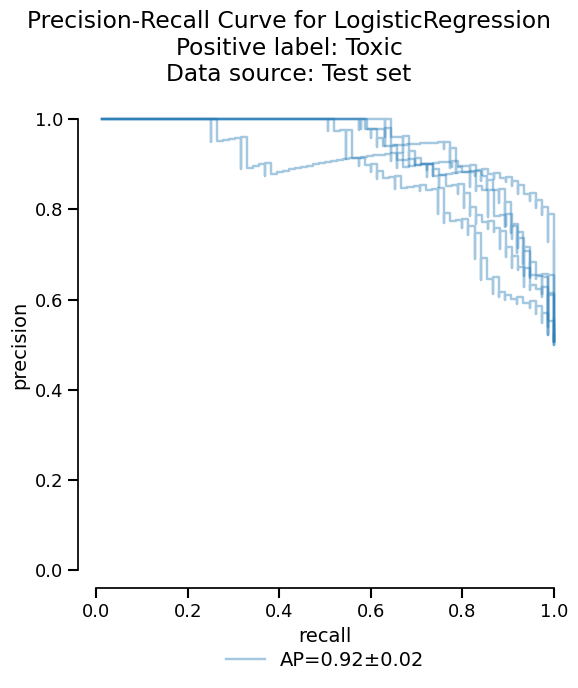

In [11]:
# We can visualize the critical information as a plot, with only a few lines of code:.

precision_recall.plot()

In [12]:
# Or we can access the raw information as a dataframe if additional analysis is needed.

precision_recall.frame()

,split,threshold,precision,recall
0,0,0.003018,0.506667,1.000000
1,0,0.028402,0.524138,1.000000
2,0,0.028555,0.520833,0.986842
3,0,0.095186,0.609756,0.986842
4,0,0.098096,0.606557,0.973684
...,...,...,...,...
469,4,0.992720,1.000000,0.066667
470,4,0.993688,1.000000,0.053333
471,4,0.996694,1.000000,0.040000
472,4,0.997928,1.000000,0.026667


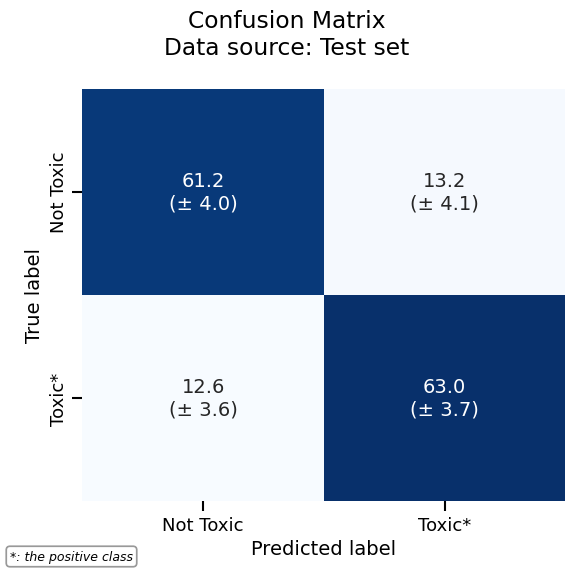

In [14]:
# As another example, we can plot the confusion matrix with the same consistent API.

confusion_matrix = logreg_cv_report.metrics.confusion_matrix()
confusion_matrix.plot()

In [15]:
# Skore also provides utilities to inspect models. Since our model is a linear model, we can study the importance that it gives to each feature.

coefficients = logreg_cv_report.inspection.coefficients()
coefficients.frame()

,feature,coefficient_mean,coefficient_std
0,Intercept,-0.229594,0.073703
1,text_00,0.525716,0.056630
2,text_01,0.632411,0.196744
3,text_02,-0.027981,2.314581
4,text_03,0.333833,1.086674
5,text_04,1.132879,1.275688
6,text_05,0.183052,0.889087
7,text_06,0.419226,0.330006
8,text_07,-0.027887,0.368701
9,text_08,-0.055355,0.710572


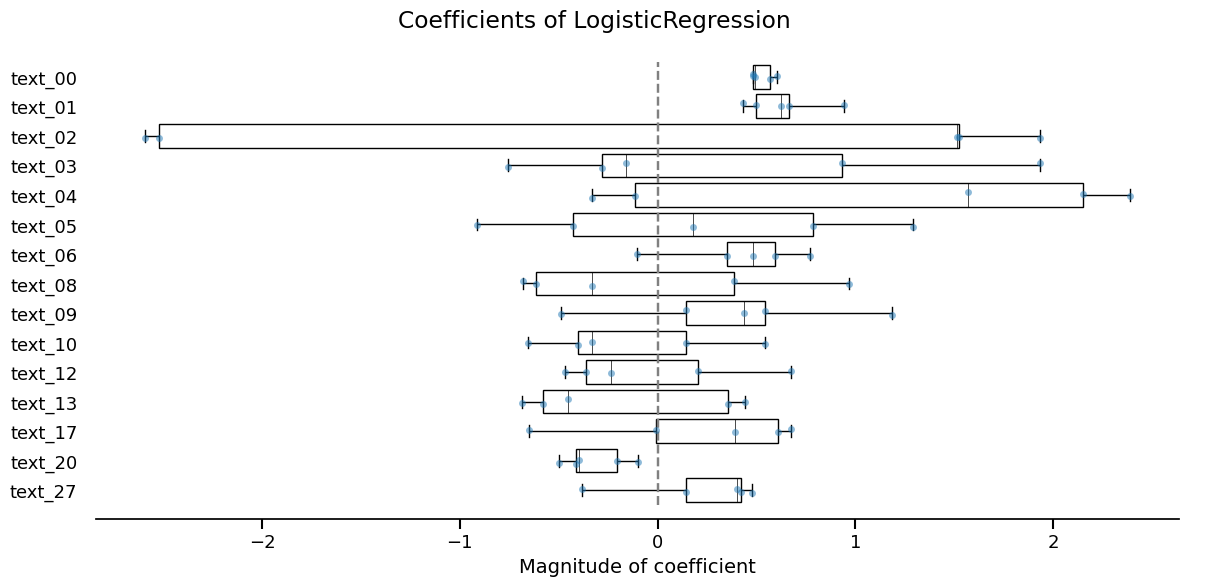

In [16]:
coefficients.plot(select_k=15)

# Model no. 2:

In [17]:
# Model no. 2: Random forest.
# Now, we cross-validate a more powerful model using RandomForestClassifier. Again, we rely on tabular_pipeline() to perform the appropriate preprocessing to use with this model.


from sklearn.ensemble import RandomForestClassifier

random_forest = tabular_pipeline(RandomForestClassifier(random_state=0))
random_forest

,steps,"[('tablevectorizer', ...), ('randomforestclassifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,cardinality_threshold,40
,low_cardinality,OrdinalEncode...nown_value=-1)
,high_cardinality,StringEncoder()
,numeric,PassThrough()
,datetime,DatetimeEncoder()
,specific_transformers,()
,drop_null_fraction,1.0


In [18]:
rf_cv_report = evaluate(
    random_forest, X_experiment, y_experiment, pos_label="Toxic", splitter=5
)
rf_cv_report

Output()

Output()

Output()

Output()

Output()

Output()

Output()

Output()

Output()

Output()

Output()

Metric,mean,std
Accuracy,0.813333,0.024944
Precision,0.848676,0.033904
Recall,0.767158,0.034897
ROC AUC,0.880557,0.031871
Log loss,0.454588,0.036559
Brier score,0.144111,0.014724
Fit time (s),12.673815,8.666341
Predict time (s),0.287588,0.140528
,steps,"[('tablevectorizer', ...), ('randomforestclassifier', ...)]"
,transform_input,None


In [19]:
rf_cv_report.checks.summarize()

Output()

Checks summary: 2 issue(s), 3 tip(s), 6 passed, 5 not applicable, 0 skipped, 0 ignored.
Issues:
- [SKD001] Potential overfitting. Significant train/test gaps were found for 6/6 default predictive metrics. Read more about this here: https://docs.skore.probabl.ai/0.24/user_guide/automated_checks.html#skd001-overfitting.
- [SKD010] Model slower than baseline. Fit time is ~5.1x slower than a fast linear baseline without significantly better test scores (6/6 default predictive metrics). Read more about this here: https://docs.skore.probabl.ai/0.24/user_guide/automated_checks.html#skd010-slower-than-baseline.
Tips:
- [SKD007] MDI biased for high-cardinality features. High-cardinality features detected: text_00, text_01, text_02 (and 27 more). Mean Decrease in Impurity (MDI) importance is biased toward such features. Consider using permutation importance for a more robust alternative. Read more about this here: https://docs.skore.probabl.ai/0.24/user_guide/automated_checks.html#skd007-mdi-cardinality-bias.
- [SKD009] Model performance vs. HistGradientBoosting baseline. Your model is on par with or better than a HistGradientBoosting baseline. Baseline performance on the test set, for reference: Accuracy=0.78, Brier score=0.166, Log loss=0.574, Precision=0.797, ROC AUC=0.863, Recall=0.762. Read more about this here: https://docs.skore.probabl.ai/0.24/user_guide/automated_checks.html#skd009-worse-than-baseline.
- [SKD016] Estimator not tuned. Estimator(s) left at default settings; consider tuning: ['max_features', 'min_samples_leaf'] for RandomForestClassifier. Read more about this here: https://docs.skore.probabl.ai/0.24/user_guide/automated_checks.html#skd016-estimator-not-tuned.
Passed:
- [SKD002] Potential underfitting
- [SKD003] Inconsistent performance across splits
- [SKD004] High class imbalance
- [SKD008] Highly correlated input features
- [SKD011] Golden feature
- [SKD012] Useless features
Not Applicable:
- [SKD005] Underrepresented classes. ML task is not multiclass classification. Got binary-classification. Read more about this here: https://docs.skore.probabl.ai/0.24/user_guide/automated_checks.html#skd005-underrepresented-classes.
- [SKD006] Coefficient interpretation. Estimator is not a linear model: it does not have a `coef_` attribute. Read more about this here: https://docs.skore.probabl.ai/0.24/user_guide/automated_checks.html#skd006-unscaled-coefficients.
- [SKD013] Train-test overlap in time series. No datetime column found. Read more about this here: https://docs.skore.probabl.ai/0.24/user_guide/automated_checks.html#skd013-train-test-time-overlap.
- [SKD014] Hyperparameters at search edge. Estimator is not a BaseSearchCV instance. Got Pipeline. Read more about this here: https://docs.skore.probabl.ai/0.24/user_guide/automated_checks.html#skd014-hyperparams-at-search-edge.
- [SKD015] Hyperparameters worth tuning. Estimator is not a BaseSearchCV instance. Got Pipeline. Read more about this here: https://docs.skore.probabl.ai/0.24/user_guide/automated_checks.html#skd015-hyperparameters-worth-tuning.
Mute a check with .checks.summarize(ignore=['<code>']).

# Comparing our models

In [20]:
# Now that we have our two models, we need to decide which one should go into production. We can compare them with the compare() function that returns a ComparisonReport.

from skore import compare

comparison = compare(
    {
        "logistic regression": logreg_cv_report,
        "random forest": rf_cv_report,
    },
)
comparison

Output()

Output()

Output()

Output()

ComparisonReport:
        ['logistic regression', 'random forest']

                         logistic regression random forest logistic regression  \
                                mean          mean                 std   
Metric                                                                   
Accuracy                    0.828000      0.813333            0.040387   
Precision                   0.827953      0.848676            0.047129   
Recall                      0.833298      0.767158            0.048512   
ROC AUC                     0.905555      0.880557            0.036318   
Log loss                    0.386408      0.454588            0.056205   
Brier score                 0.123921      0.144111            0.022232   
Fit time (s)                5.965415     12.673815            2.933636   
Predict time (s)            0.296566      0.287588            0.101437   

                 random forest  
                           std  
Metric                          
Accuracy              0.024944  
Precision             0.033904  
Recall                0.034897  
ROC AUC               0.031871  
Log loss              0.036559  
Brier score           0.014724  
Fit time (s)          8.666341  
Predict time (s)      0.140528  
        Call `report.to_markdown()` for a markdown summary of the report's contents.

In [21]:
# This report follows the same API as CrossValidationReport.

comparison.help()

In [22]:
# We have access to the same tools to perform statistical analysis and compare both models.

comparison_metrics = comparison.metrics.summarize()
comparison_metrics.frame(favorability=True)

Output()

,mean_logistic_regression,mean_random_forest,std_logistic_regression,std_random_forest,favorability
metric,,,,,
accuracy,0.828000,0.813333,0.040387,0.024944,(↗︎)
precision,0.827953,0.848676,0.047129,0.033904,(↗︎)
recall,0.833298,0.767158,0.048512,0.034897,(↗︎)
roc_auc,0.905555,0.880557,0.036318,0.031871,(↗︎)
log_loss,0.386408,0.454588,0.056205,0.036559,(↘︎)
brier_score,0.123921,0.144111,0.022232,0.014724,(↘︎)
fit_time,5.965415,12.673815,2.933636,8.666341,(↘︎)
predict_time,0.296566,0.287588,0.101437,0.140528,(↘︎)


Output()

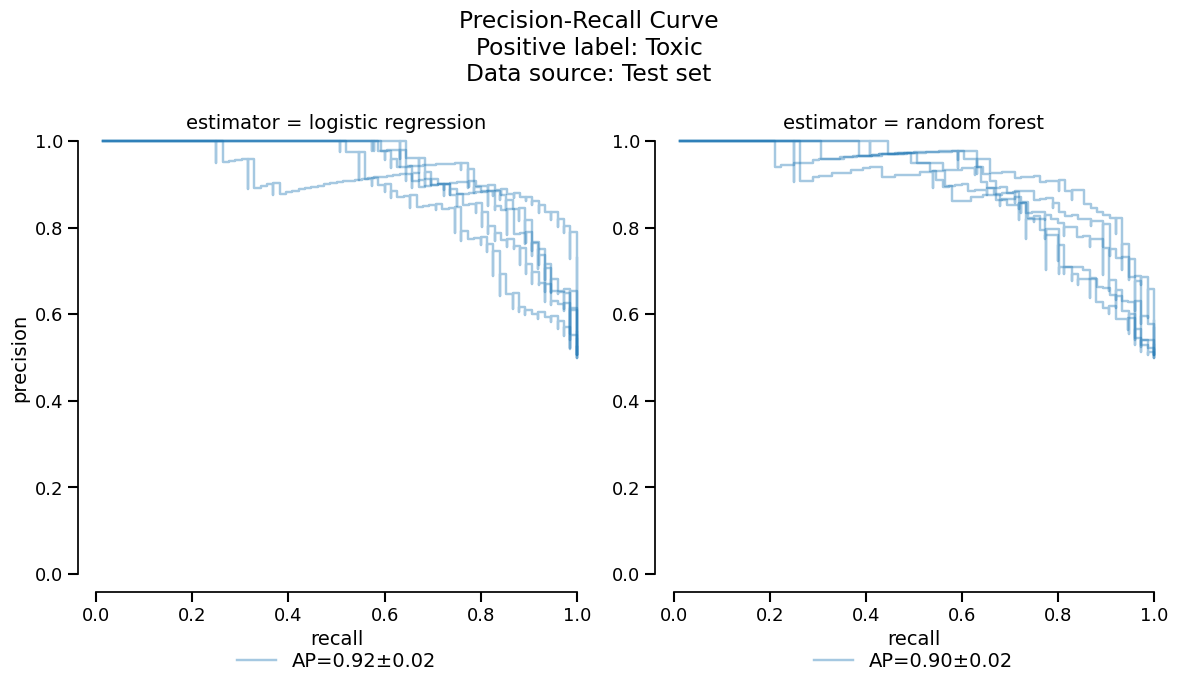

In [23]:
comparison.metrics.precision_recall().plot()

In [ ]:
# Based on the previous tables and plots, it seems that the RandomForestClassifier model 
# has slightly worse performance due to overfitting on this small dataset. We make the choice to deploy the linear model to make a comparison with the coefficients study shown earlier.

# Final model evaluation on held-out data.

In [24]:
# Now that we have chosen to deploy the linear model, we will train it on the full experiment set and evaluate it on our held-out data: training on more data should help performance and we can also validate that our model generalizes well to new data. This can be done in one step with create_estimator_report().

final_report = comparison.create_estimator_report(
    report_key="logistic regression", X_test=X_holdout, y_test=y_holdout
)
final_report

EstimatorReport:
        'LogisticRegression'

        Metric
Accuracy            0.832000
Precision           0.846154
Recall              0.804878
ROC AUC             0.914410
Log loss            0.359656
Brier score         0.115962
Fit time (s)        3.604210
Predict time (s)    0.442015
Name: LogisticRegression, dtype: float64
        Call `report.to_markdown()` for a markdown summary of the report's contents.

In [25]:
# This returns a EstimatorReport which has a similar API to the other report classes.

final_metrics = final_report.metrics.summarize()
final_metrics.frame()

metric
accuracy        0.832000
precision       0.846154
recall          0.804878
roc_auc         0.914410
log_loss        0.359656
brier_score     0.115962
fit_time        3.604210
predict_time    0.442015
Name: LogisticRegression, dtype: float64

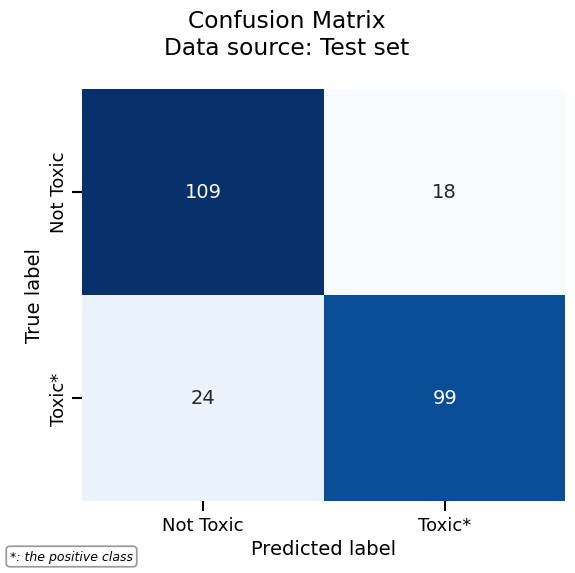

In [26]:
final_report.metrics.confusion_matrix().plot()

In [28]:
# We can easily combine the results of the previous cross-validation together with the evaluation on the held-out dataset, since the two are accessible as tables. This way, we can check if our chosen model meets the expectations we set during the experiment phase.

final_frame = final_metrics.frame().to_frame()
cv_frame = logreg_cv_report.metrics.summarize().frame()
final_frame.merge(cv_frame, on="metric", how="outer")

Output()

,LogisticRegression,logisticregression_mean,logisticregression_std
metric,,,
accuracy,0.832000,0.828000,0.040387
brier_score,0.115962,0.123921,0.022232
fit_time,3.604210,5.965415,2.933636
log_loss,0.359656,0.386408,0.056205
precision,0.846154,0.827953,0.047129
predict_time,0.442015,0.296566,0.101437
recall,0.804878,0.833298,0.048512
roc_auc,0.914410,0.905555,0.036318


In [29]:
# As expected, our final model gets better performance, likely thanks to the larger training set.

# Our final sanity check is to compare the features considered most impactful between our final model and the cross-validation.

final_coefficients = final_report.inspection.coefficients()
cv_coefficients = logreg_cv_report.inspection.coefficients()

features_final_coefficients = final_coefficients.frame(select_k=15)["feature"]
features_cv_coefficients = cv_coefficients.frame(select_k=15)["feature"]

print(
    f"Most important features available in both models: "
    f"{set(features_final_coefficients).intersection(set(features_cv_coefficients))}"
)

print(
    f"Most important features available in final model but not in cross-validation: "
    f"{set(features_final_coefficients).difference(set(features_cv_coefficients))}"
)

Most important features available in both models: {'text_06', 'text_12', 'text_01', 'text_04', 'text_09', 'text_02', 'text_00'}
Most important features available in final model but not in cross-validation: {'text_25', 'text_19', 'text_28', 'text_26', 'Intercept', 'text_16', 'text_29', 'text_24'}


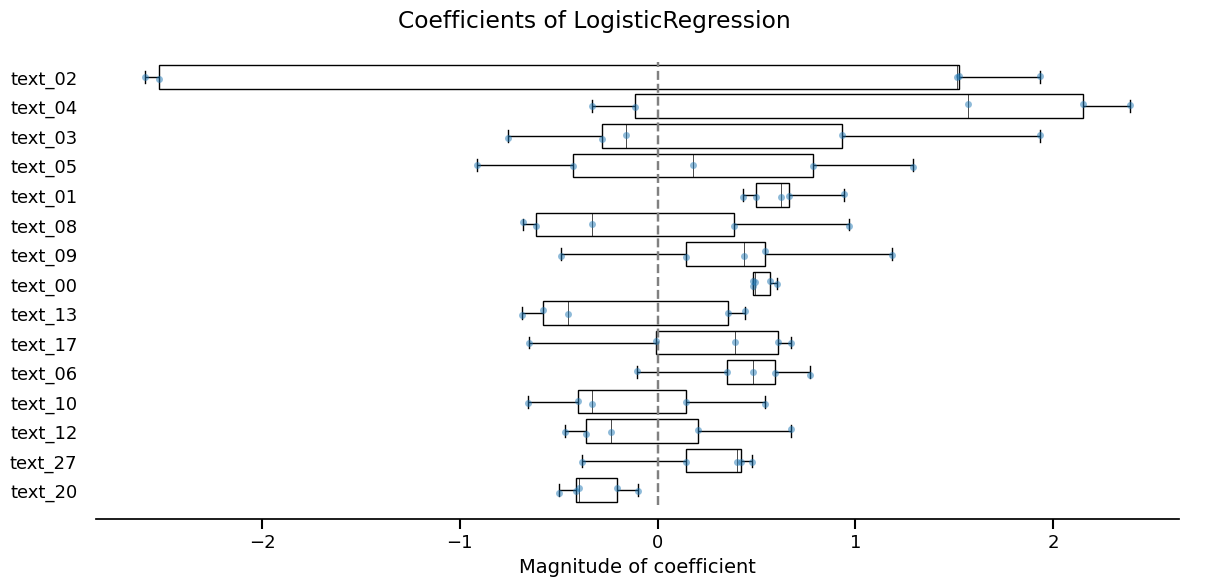

In [30]:
# We can further check if there is a drastic difference in the ordering by plotting those features with the largest absolute coefficients.

final_coefficients.plot(select_k=15, sorting_order="descending")
cv_coefficients.plot(select_k=15, sorting_order="descending")

# Tracking our work with a skore Project.

In [31]:
# Here, we are using Skore Hub to store and analyze the reports that we computed. Note that you can store reports as well locally using mode="local" when creating or loading projects via skore.Project.

from skore import login

login()

Output()

In [ ]:
# We load or create a hub project.

from skore import Project
project = Project(name="PROJECT_01", mode="hub", workspace="davidguzzi")

c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\skore\_plugins\hub\project\project.py:115: UserWarning: Your project will be created as 'project_01'. The project name must be lower-case and contain only ASCII letters, digits, and characters '.', '-', and '_'.
  return method(*args, **kwargs)


In [36]:
# We store our reports with descriptive keys.

project.put("logreg_cv", logreg_cv_report)

Output()

Consult your report at 
]8;id=2914576;https://skore.probabl.ai/davidguzzi/project_01/cross-validations/38595\https://skore.probabl.ai/davidguzzi/project_01/cross-validations/38595]8;;\

In [37]:
project.put("rf_cv", rf_cv_report)

Output()

Consult your report at 
]8;id=2914579;https://skore.probabl.ai/davidguzzi/project_01/cross-validations/38601\https://skore.probabl.ai/davidguzzi/project_01/cross-validations/38601]8;;\

In [38]:
# In this example, we created a read-only Skore Hub project that you can visit by clicking on the link above and explore the reports.

# Now we can retrieve a summary of our stored reports.


summary = project.summarize()
summary

report_id  \
  id                                                                          
0 skore:report:cross-validation:38595  01a00745-47cf-717b-923f-2d77179fb729   
1 skore:report:cross-validation:38601  01a00763-9c4f-7394-8aa2-c4cc31166735   

                                             key  \
  id                                               
0 skore:report:cross-validation:38595  logreg_cv   
1 skore:report:cross-validation:38601      rf_cv   

                                                                  date  \
  id                                                                     
0 skore:report:cross-validation:38595 2026-08-15 22:24:16.124629+00:00   
1 skore:report:cross-validation:38601 2026-08-15 22:35:28.749322+00:00   

                                                      learner  \
  id                                                            
0 skore:report:cross-validation:38595      LogisticRegression   
1 skore:report:cross-validation:38601  RandomForestClassifier   

                                                     ml_task  \
  id                                                           
0 skore:report:cross-validation:38595  binary-classification   
1 skore:report:cross-validation:38601  binary-classification   

                                            report_type  \
  id                                                      
0 skore:report:cross-validation:38595  cross-validation   
1 skore:report:cross-validation:38601  cross-validation   

                                                                dataset  rmse  \
  id                                                                            
0 skore:report:cross-validation:38595  2cb314e3e76adb323fdbf0f664650d40  None   
1 skore:report:cross-validation:38601  2cb314e3e76adb323fdbf0f664650d40  None   

                                       log_loss   roc_auc   fit_time  \
  id                                                                   
0 skore:report:cross-validation:38595  0.386408  0.905555   5.965415   
1 skore:report:cross-validation:38601  0.454588  0.880557  12.673815   

                                       predict_time rmse_std  log_loss_std  \
  id                                                                         
0 skore:report:cross-validation:38595      0.296566     None      0.056205   
1 skore:report:cross-validation:38601      0.287588     None      0.036559   

                                       roc_auc_std  fit_time_std  \
  id                                                               
0 skore:report:cross-validation:38595     0.036318      2.933636   
1 skore:report:cross-validation:38601     0.031871      8.666341   

                                       predict_time_std  
  id                                                     
0 skore:report:cross-validation:38595          0.101437  
1 skore:report:cross-validation:38601          0.140528

In [39]:
# summarize() returns a Summary object. In a Jupyter environment it renders as an interactive table where you can filter rows and pick reports across the different views; the selection produces a query string ready to pass to query() so you can recover exactly those reports.

# Once you filtered the summary (e.g. to keep only the cross-validation reports), if you now call compare(), you get only the CrossValidationReport objects, which you can directly put in the form of a ComparisonReport.

new_report = summary.query('report_type == "cross-validation"').compare(
    return_as="report"
)
new_report

Output()

Output()

Output()

Output()

Output()

Output()

Output()

Output()

Output()

Output()

Output()

Output()

Output()

Output()

Output()

Output()

Output()

Output()

Output()

Output()

ComparisonReport:
        ['LogisticRegression', 'RandomForestClassifier']

                         LogisticRegression RandomForestClassifier LogisticRegression  \
                               mean                   mean                std   
Metric                                                                          
Accuracy                   0.828000               0.813333           0.040387   
Precision                  0.827953               0.848676           0.047129   
Recall                     0.833298               0.767158           0.048512   
ROC AUC                    0.905555               0.880557           0.036318   
Log loss                   0.386408               0.454588           0.056205   
Brier score                0.123921               0.144111           0.022232   
Fit time (s)               5.965415              12.673815           2.933636   
Predict time (s)           0.708429               0.906239           0.833191   

                 RandomForestClassifier  
                                    std  
Metric                                   
Accuracy                       0.024944  
Precision                      0.033904  
Recall                         0.034897  
ROC AUC                        0.031871  
Log loss                       0.036559  
Brier score                    0.014724  
Fit time (s)                   8.666341  
Predict time (s)               0.735865  
        Call `report.to_markdown()` for a markdown summary of the report's contents.